Insertion sort vs Merge sort vs Quick sort on SMALL lists. We will show specific cases where Insertion sort does better than the other two, as well as cases where it is most definitely worse.

In [19]:
from auxilary.bad_sorts import create_random_list, insertion_sort
from auxilary.good_sorts import mergesort, quicksort
import matplotlib.pyplot as plt
import timeit

In [20]:
def annotate_crossover(idx, lengths, times, plt):
    cx = lengths[idx]
    cy = times[idx] # The time at the crossover
    # Place a black dot at the intersection
    plt.scatter([cx], [cy], color='black', zorder=5) 
    
    # Add an annotation with an arrow
    plt.annotate(f'Crossover @ N={cx}', 
                 xy=(cx, cy),              # Point to arrow tip
                 xytext=(cx + 10, cy + 0.00005), # Where text sits (adjust offset as needed)
                 arrowprops=dict(facecolor='black', shrink=0.05))
def random_reverse_sorted_list(max_value):
    return list(range(max_value, 0, -1))

In [ ]:
# intiialise lists of fixed lengths for now
# Create a list of lengths from 100 to 50,000 with a step of 250
lengths = list(range(0, 150, 3))
lists = [create_random_list(l, 10000) for l in lengths]

# for each list we will time it, graph the times
n = len(lists)
insertion_times, mergesort_times, quicksort_times = [], [], []
# tests per list, take the best occurence
trials = 1000
for i in range(n):
    
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        insertion_sort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    insertion_times.append(best)

    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        mergesort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    mergesort_times.append(best)

    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        quicksort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    quicksort_times.append(best)


plt.plot(lengths, insertion_times, color='red')
plt.plot(lengths, mergesort_times, color='blue')
plt.plot(lengths, quicksort_times, color='green')
plt.legend(['insertion sort', 'mergesort', 'quicksort'])
plt.xlabel('List Length')
plt.ylabel('Time (seconds)')
plt.title('Runtime of insertion sort vs mergesort vs quicksort for random lists of length 0 to 150')
plt.show()

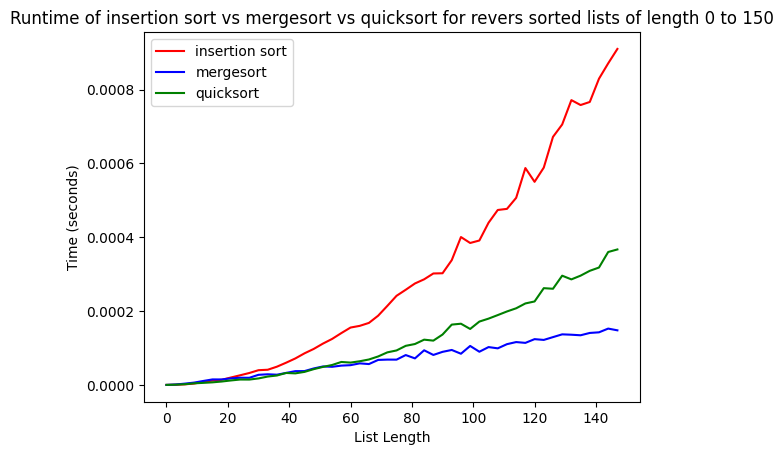

In [ ]:
# random reversed lists only
lengths = list(range(0, 150, 3))
lists = [random_reverse_sorted_list(l) for l in lengths]

# for each list we will time it, graph the times
n = len(lists)
insertion_times, mergesort_times, quicksort_times = [], [], []
# tests per list, take the best occurence
trials = 1000
for i in range(n):
    
    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        insertion_sort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    insertion_times.append(best)

    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        mergesort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    mergesort_times.append(best)

    best = float('inf')
    for _ in range(trials):
        l1 = lists[i][:]
        start = timeit.default_timer()
        quicksort(l1)
        elapsed = timeit.default_timer() - start
        best = min(best, elapsed)
    quicksort_times.append(best)


# for i in range(n):
#     # Look for the moment Insertion becomes slower than Merge 
#     if insertion_times[i] > mergesort_times[i]:
#         annotate_crossover(i, lengths, mergesort_times, plt)
#         break

# for i in range(n):
#     # Look for the moment Insertion becomes slower than quick 
#     if insertion_times[i] > quicksort_times[i]:
#         annotate_crossover(i, lengths, quicksort_times, plt)
#         break

plt.plot(lengths, insertion_times, color='red')
plt.plot(lengths, mergesort_times, color='blue')
plt.plot(lengths, quicksort_times, color='green')
plt.legend(['insertion sort', 'mergesort', 'quicksort'])
plt.xlabel('List Length')
plt.ylabel('Time (seconds)')
plt.title('Runtime of insertion sort vs mergesort vs quicksort for revers sorted lists of length 0 to 150')
plt.show()